# Pooled data0 + data1 + data2: grouped modelling and evaluation

Run top to bottom with the project's `.venv` kernel, or run `python -m scripts.run_modelling` from the repository root.
Train **one pooled model** and report validation/test performance separately for each dataset as well as overall.
Training-only five-fold GroupKFold selects the model; validation selects one shared F1 threshold; test is evaluated last.

**Observation:** one `(dataset, transcript_id, transcript_position)` site, aggregated over all its reads.
Overlapping human sites remain separate dataset observations, but **the same human gene always shares one group across data0/data1**.
For data2, `geo_reference_id` defines four synthetic construct groups; all mixtures of a construct stay together.
Its `tx_id_*` values each contain multiple constructs and must not be treated as gene IDs.
The annotated data2 target is `label_original > 0` (positive mixture at a site, not a per-read modification label).

The common X table has **153 engineered + 9 raw mean features = 162 columns**; each model selects its own feature subset.
Dataset, group, gene, mixture label and reference annotations are metadata, never predictors.
Candidates include mean-signal HGB, sequence-only/full logistic regression, HGB and XGBoost with fold-local weighting and fixed random searches.
All candidates reuse the same folds and are selected by mean pooled CV AP (ROC-AUC breaks ties).
This weights sites equally, not datasets equally. Per-dataset reports expose differences hidden by the pooled score.

Earlier project analyses inspected these datasets. This new pooled split is an internal evaluation, not a new external cohort,
and its numbers must not be compared as if they used the historical data0-only test membership.


## 1. Environment and reproducible configuration

Install dependencies with `python -m pip install -r requirements.txt`; on macOS XGBoost also needs `brew install libomp`.
If annotated files are missing, run `python -m scripts.prepare_datasets --download` first.
The three inputs are `data/processed/annotated/data{0,1,2}_reads.parquet`.
Keep the group split and CV seed fixed. Each Run All creates a new run directory.
The default plan runs 21 experiments × 5 folds, plus final refits. CLI `--prepare-only` stops after saving split/features without training.


In [1]:
from pathlib import Path
import sys
import json
import gc
import hashlib
import uuid
from datetime import datetime
from zoneinfo import ZoneInfo
from itertools import combinations

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

import warnings
from time import perf_counter
import joblib
import sklearn
import xgboost
from xgboost import XGBClassifier
from sklearn.model_selection import GroupKFold, ParameterSampler
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, average_precision_score, auc, balanced_accuracy_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_recall_curve, precision_score, recall_score,
    roc_auc_score, roc_curve,
)
from threadpoolctl import threadpool_limits

ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "src/feature_engineering.py").is_file()),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Start this notebook from the repository root or notebooks/ directory.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.feature_engineering import FEATURE_COLUMNS, RAW_FEATURE_NAMES, SITE_KEY_COLUMNS
from src.modelling_data import (
    DATASETS, OBSERVATION_KEYS, RAW_MEAN_COLUMNS, MODEL_FEATURE_COLUMNS,
    load_site_metadata, assign_group_splits, validate_splits, build_pooled_features,
)

SEED = 42
SPLIT_RATIOS = (0.70, 0.15, 0.15)
SPLIT_NAMES = ("train", "val", "test")
BATCH_SIZE = 200_000  # Process complete sites in read batches to limit memory use
SAVE_OUTPUTS = True
MODEL_THREADS = int(globals().get("MODEL_THREADS", 4))
BOOTSTRAP_REPEATS = 500
CV_FOLDS = 5
SEARCH_CANDIDATES_PER_FAMILY = 6
LOCAL_TZ = ZoneInfo("Asia/Singapore")
RUN_ID = datetime.now(LOCAL_TZ).strftime("%Y%m%dT%H%M%S") + "_" + uuid.uuid4().hex[:8]
PROCESSED_DIR = Path(globals().get("PROCESSED_DIR", ROOT / "data/processed")).resolve()
READS_PATHS = {name: PROCESSED_DIR / "annotated" / f"{name}_reads.parquet" for name in DATASETS}
OUTPUT_BASE = PROCESSED_DIR / "modelling" / f"pooled_data0_data1_data2_group_split_seed{SEED}"
OUTPUT_DIR = OUTPUT_BASE / "person_c_runs" / RUN_ID
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 12)
print("Project:", ROOT)
print("Parquets:", READS_PATHS)

print("Run ID:", RUN_ID)
print("Output:", OUTPUT_DIR)


Project: /Users/jiacheng/Documents/GitHub/DSA4262_Genomies
Parquets: {'data0': PosixPath('/Users/jiacheng/Documents/GitHub/DSA4262_Genomies/data/processed/annotated/data0_reads.parquet'), 'data1': PosixPath('/Users/jiacheng/Documents/GitHub/DSA4262_Genomies/data/processed/annotated/data1_reads.parquet'), 'data2': PosixPath('/Users/jiacheng/Documents/GitHub/DSA4262_Genomies/data/processed/annotated/data2_reads.parquet')}
Run ID: 20261006T085253_d868f3c6
Output: /Users/jiacheng/Documents/GitHub/DSA4262_Genomies/data/processed/modelling/pooled_data0_data1_data2_group_split_seed42/person_c_runs/20261006T085253_d868f3c6


In [2]:
# Validate all three inputs before creating a run directory or fitting anything.
sites = load_site_metadata(READS_PATHS)
if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=False)
print("Loaded site metadata for:", ", ".join(DATASETS))


Loaded site metadata for: data0, data1, data2


## 2. Site metadata and data checks

Read the first read of each site for metadata; feature engineering uses every read.
Validate binary targets, complete coverage, human transcript-to-gene consistency across datasets and synthetic construct annotations.
Keep source dataset, original mixture proportions and reference mapping evidence for audit and per-dataset reporting.


In [3]:
display(sites.groupby("dataset").agg(
    sites=("label", "size"), groups=("group_id", "nunique"),
    reads=("n_reads", "sum"), positives=("label", "sum"), positive_rate=("label", "mean"),
))
human_sites = sites.loc[sites["group_kind"].eq("human_gene")]
overlap_sites = human_sites.groupby(SITE_KEY_COLUMNS)["dataset"].nunique().eq(2).sum()
overlap_genes = human_sites.groupby("gene_id")["dataset"].nunique().eq(2).sum()
print(f"data0/data1 shared sites: {overlap_sites:,}; shared genes: {overlap_genes:,}")
print("Overlapping observations are retained in the same group, not averaged across datasets.")
display(sites.head())


,sites,groups,reads,positives,positive_rate
dataset,,,,,
data0,121838,3852,11027106,5475,0.044937
data1,90810,3149,7907952,6593,0.072602
data2,1323,4,1171940,1134,0.857143


data0/data1 shared sites: 67,320; shared genes: 2,515
Overlapping observations are retained in the same group, not averaged across datasets.


,transcript_id,transcript_position,sequence,n_reads,gene_id,label,...,dataset,central_5mer,geo_reference_id,geo_reference_center_0based,reference_mapping_status,label_original
0,ENST00000000233,244,AAGACCA,185,ENSG00000004059,0,...,data0,AGACC,NaN,NaN,NaN,NaN
1,ENST00000000233,261,CAAACTG,172,ENSG00000004059,0,...,data0,AAACT,NaN,NaN,NaN,NaN
2,ENST00000000233,316,GAAACAG,185,ENSG00000004059,0,...,data0,AAACA,NaN,NaN,NaN,NaN
3,ENST00000000233,332,AGAACAT,200,ENSG00000004059,0,...,data0,GAACA,NaN,NaN,NaN,NaN
4,ENST00000000233,368,AGGACAA,198,ENSG00000004059,0,...,data0,GGACA,NaN,NaN,NaN,NaN


## 3. Split train / validation / test by shared gene or construct

Sort and shuffle the **union of human gene IDs** with a fixed seed, then split approximately 70% / 15% / 15% by gene count.
Independently shuffle the four synthetic construct IDs: the default ratios allocate **2 train / 1 validation / 1 test**.
All data2 mixtures of a construct remain together, including reused endpoint read signals.
No label-based seed search is performed. Every dataset must have both classes in every partition; actual counts are reported below.
Human transcript IDs must be disjoint between splits; synthetic mixture transcript IDs may recur because grouping is by source construct.


In [4]:
sites["split"] = assign_group_splits(sites, SPLIT_RATIOS, SEED)
split_dataset_summary = validate_splits(sites)
split_summary = sites.groupby("split").agg(
    sites=("label", "size"), groups=("group_id", "nunique"), reads=("n_reads", "sum"),
    positives=("label", "sum"), positive_rate=("label", "mean"),
).reindex(SPLIT_NAMES)
split_summary["negatives"] = split_summary["sites"] - split_summary["positives"]
split_summary["site_fraction"] = split_summary["sites"] / len(sites)
display(split_summary, split_dataset_summary)
print("PASS: human genes across datasets and synthetic constructs across mixtures are disjoint between splits.")


,sites,groups,reads,positives,positive_rate,negatives,site_fraction
split,,,,,,,
train,149476,3142,13943396,9072,0.060692,140404,0.698581
val,31729,674,3094327,2037,0.064200,29692,0.148286
test,32766,674,3069275,2093,0.063877,30673,0.153133


sites  groups    reads  positives  positive_rate  negatives
dataset split                                                             
data0   train  85166    2696  7765313       3845       0.045147      81321
        val    17735     575  1621530        793       0.044714      16942
        test   18937     581  1640263        837       0.044199      18100
data1   train  63568    2196  5555131       4591       0.072222      58977
        val    13665     480  1157077        962       0.070399      12703
        test   13577     473  1195744       1040       0.076600      12537
data2   train    742       2   622952        636       0.857143        106
        val      329       1   315720        282       0.857143         47
        test     252       1   233268        216       0.857143         36

PASS: human genes across datasets and synthetic constructs across mixtures are disjoint between splits.


## 4. Training-set EDA

Explore training data only. Model and hyperparameter selection will use grouped CV within train;
validation is reserved for the decision threshold. Internal test data is evaluated after all decisions are locked.
The existing `EDA_Findings.ipynb` contains broader, earlier exploration of the full dataset.


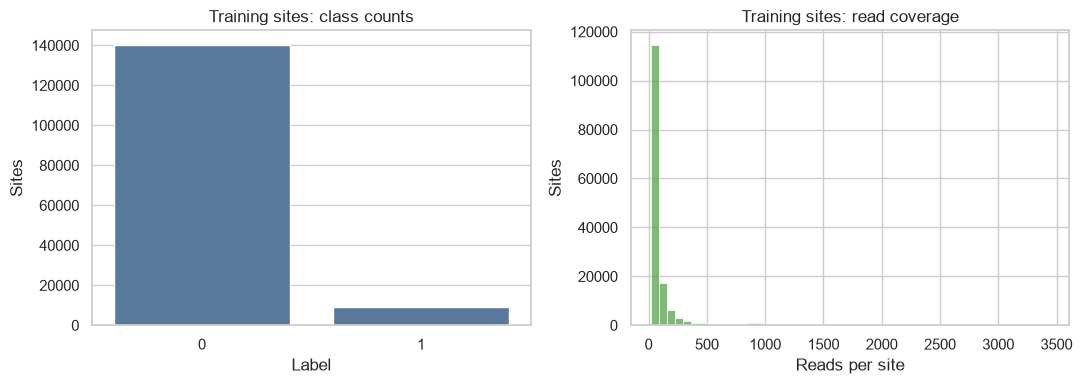

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,140404.0,89.723754,143.601381,20.0,29.0,44.0,82.0,1949.0
1,9072.0,148.348986,276.851853,20.0,31.0,52.0,117.0,3438.0


In [5]:
train_sites = sites.loc[sites["split"].eq("train")].copy()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(data=train_sites, x="label", ax=axes[0], color="#4c78a8")
axes[0].set(title="Training sites: class counts", xlabel="Label", ylabel="Sites")
sns.histplot(data=train_sites, x="n_reads", bins=50, ax=axes[1], color="#59a14f")
axes[1].set(title="Training sites: read coverage", xlabel="Reads per site", ylabel="Sites")
plt.tight_layout()
plt.show()
display(train_sites.groupby("label")["n_reads"].describe())


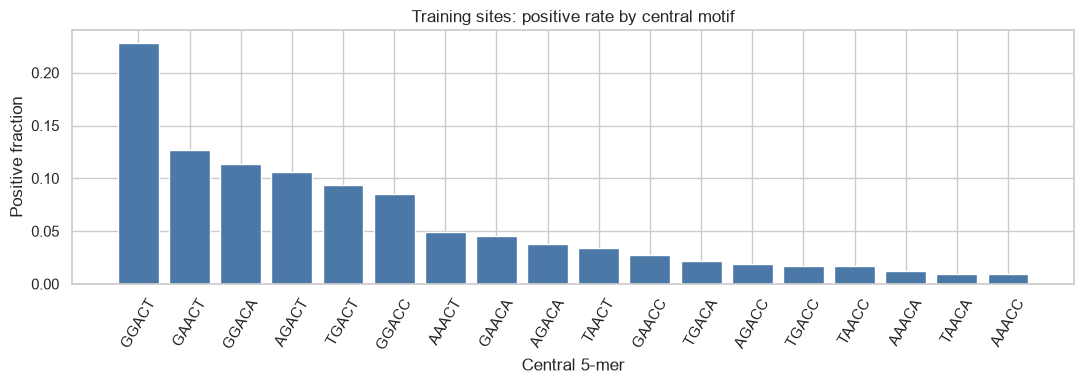

,sites,positives,positive_rate
central_5mer,,,
GGACT,8365,1912,0.228571
GAACT,8352,1063,0.127275
GGACA,10016,1139,0.113718
AGACT,7828,832,0.106285
TGACT,8560,798,0.093224
GGACC,9859,838,0.084998
AAACT,9804,481,0.049062
GAACA,9699,436,0.044953
AGACA,9011,337,0.037399


In [6]:
motif_summary = (
    train_sites.groupby("central_5mer")["label"]
    .agg(sites="size", positives="sum", positive_rate="mean")
    .sort_values("positive_rate", ascending=False)
)
fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(motif_summary.index, motif_summary["positive_rate"], color="#4c78a8")
ax.set(title="Training sites: positive rate by central motif", xlabel="Central 5-mer", ylabel="Positive fraction")
ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()
display(motif_summary)


## 5. Site feature engineering and the raw-mean baseline

Reuse `build_features` to create the existing **153 engineered features**: log dwell, centre/flank contrasts, site summaries,
coverage, position-wise sequence and central motif encodings. Separately compute the **arithmetic mean of each of the nine raw signals** at each site.
These nine extra columns define the mean-only boosting baseline; they do not include sequence, coverage, transformed dwell or higher-order statistics.

The shared feature table has 162 columns, but pipelines select exactly one feature set. The full engineered models continue to use 153 columns.
All aggregations are site-local and all categorical encodings are fixed. No population statistics are fitted before CV.
Optional k-mer residuals remain disabled; adding them would require fitting baselines separately inside each fold.

Read batches retain complete sites even when a site crosses a batch boundary. Metadata consistency, coverage and finite signals are checked.


In [7]:
# Process each dataset independently so identical transcript/site keys cannot merge.
# Streaming retains complete sites across Parquet batch boundaries.
# The shared implementation also powers inference feature construction.
site_features = build_pooled_features(READS_PATHS, sites, batch_size=BATCH_SIZE)
site_metadata = sites.set_index(OBSERVATION_KEYS).sort_index()
assert site_features.index.equals(site_metadata.index)
gc.collect()
print(f"Complete: {len(site_features):,} observations × {len(MODEL_FEATURE_COLUMNS)} available columns")


data0: processed 1,999,997 reads
data0: processed 3,999,231 reads
data0: processed 5,999,895 reads
data0: processed 7,999,946 reads
data0: processed 9,999,241 reads
data0: complete, 11,027,106 reads
data1: processed 1,999,686 reads
data1: processed 3,999,251 reads
data1: processed 5,999,580 reads
data1: processed 7,907,888 reads
data1: complete, 7,907,952 reads
data2: complete, 1,171,940 reads
Complete: 213,971 observations × 162 available columns


## 6. Prepare X_train / y_train, X_val / y_val and X_test / y_test

X is a numeric DataFrame and y is an `int8` Series, sharing the same ordered site MultiIndex.
Site identifiers remain in the index for prediction alignment, **not in feature columns**.
Use `.to_numpy()` if needed, while preserving row order.


In [8]:
def make_xy(split_name):
    meta = site_metadata.loc[site_metadata["split"].eq(split_name)].copy()
    X = site_features.loc[meta.index, MODEL_FEATURE_COLUMNS].copy()
    y = meta["label"].astype("int8").rename("label").copy()
    # Retain metadata to map predictions back to genes and sites.
    meta = meta.drop(columns="label")
    assert X.index.equals(y.index) and X.index.equals(meta.index)
    assert X.index.is_unique and not X.empty
    assert y.isin([0, 1]).all() and y.nunique() == 2
    assert np.isfinite(X.to_numpy()).all()
    assert all(pd.api.types.is_numeric_dtype(dtype) for dtype in X.dtypes)
    assert set(X.columns).isdisjoint({"label", "gene_id", "group_id", "dataset", "label_original", "transcript_id", "transcript_position", "split"})
    return X, y, meta

X_train, y_train, metadata_train = make_xy("train")
X_val, y_val, metadata_val = make_xy("val")
X_test, y_test, metadata_test = make_xy("test")

assert X_train.columns.equals(X_val.columns) and X_train.columns.equals(X_test.columns)
assert len(X_train) + len(X_val) + len(X_test) == len(sites)
assert sites["split"].equals(assign_group_splits(sites, SPLIT_RATIOS, SEED)), "The same seed must reproduce the split."

prepared = {
    "train": (X_train, y_train, metadata_train),
    "val": (X_val, y_val, metadata_val),
    "test": (X_test, y_test, metadata_test),
}
display(pd.DataFrame([
    {"split": name, "X_shape": X.shape, "y_shape": y.shape,
     "positives": int(y.sum()), "positive_rate": float(y.mean())}
    for name, (X, y, meta) in prepared.items()
]).set_index("split"))
display(X_train.head(), y_train.head())


,X_shape,y_shape,positives,positive_rate
split,,,,
train,"(149476, 162)","(149476,)",9072,0.060692
val,"(31729, 162)","(31729,)",2037,0.064200
test,"(32766, 162)","(32766,)",2093,0.063877


n_reads  minus1_log_dwell_mean  \
dataset transcript_id   transcript_position                                   
data0   ENST00000000233 244                      185              -4.980341   
                        261                      172              -5.149516   
                        316                      185              -5.030621   
                        332                      200              -4.697330   
                        368                      198              -4.738669   

                                             minus1_log_dwell_sd  \
dataset transcript_id   transcript_position                        
data0   ENST00000000233 244                             0.606104   
                        261                             0.507048   
                        316                             0.535148   
                        332                             0.557276   
                        368                             0.643782   

                                             minus1_log_dwell_min  \
dataset transcript_id   transcript_position                         
data0   ENST00000000233 244                             -6.219621   
                        261                             -6.219621   
                        316                             -6.066188   
                        332                             -6.066188   
                        368                             -6.219621   

                                             minus1_log_dwell_max  \
dataset transcript_id   transcript_position                         
data0   ENST00000000233 244                             -3.384340   
                        261                             -3.807663   
                        316                             -3.509897   
                        332                             -3.296837   
                        368                             -3.040730   

                                             minus1_log_dwell_p25  ...  \
dataset transcript_id   transcript_position                        ...   
data0   ENST00000000233 244                             -5.444500  ...   
                        261                             -5.444500  ...   
                        316                             -5.426151  ...   
                        332                             -5.039815  ...   
                        368                             -5.155195  ...   

                                             raw_mean__central_dwell  \
dataset transcript_id   transcript_position                            
data0   ENST00000000233 244                                 0.009373   
                        261                                 0.006813   
                        316                                 0.007416   
                        332                                 0.008632   
                        368                                 0.011479   

                                             raw_mean__central_signal_sd  \
dataset transcript_id   transcript_position                                
data0   ENST00000000233 244                                     7.382162   
                        261                                     3.226535   
                        316                                     3.642703   
                        332                                     2.899200   
                        368                                     5.870303   

                                             raw_mean__central_signal_mean  \
dataset transcript_id   transcript_position                                  
data0   ENST00000000233 244                                     125.913514   
                        261                                     107.889535   
                        316                                      98.947027   
                        332                                      97.836500   
                     

dataset  transcript_id    transcript_position
data0    ENST00000000233  244                    0
                          261                    0
                          316                    0
                          332                    0
                          368                    0
Name: label, dtype: int8

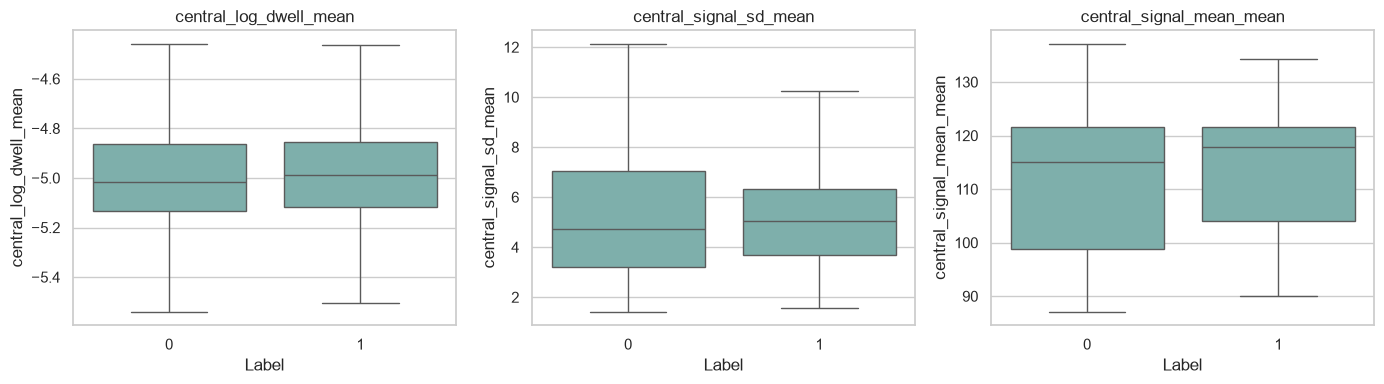

,count,mean,std,min,25%,50%,75%,max
central_log_dwell_mean,149476.0,-4.989165,0.202571,-5.676749,-5.134460,-5.012742,-4.864247,-3.911951
central_signal_sd_mean,149476.0,5.169448,2.172508,1.410913,3.237301,4.780780,6.969000,14.735556
central_signal_mean_mean,149476.0,111.250152,12.425813,87.071498,98.884158,115.346154,121.616821,137.120000
n_reads,149476.0,93.281838,155.618468,20.000000,29.000000,44.000000,83.000000,3438.000000


In [9]:
# Inspect training features only: each observation represents a site.
central_features = ["central_log_dwell_mean", "central_signal_sd_mean", "central_signal_mean_mean"]
train_feature_eda = X_train[central_features].join(y_train)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, feature in zip(axes, central_features):
    sns.boxplot(data=train_feature_eda, x="label", y=feature, showfliers=False, ax=ax, color="#76b7b2")
    ax.set(title=feature, xlabel="Label")
plt.tight_layout()
plt.show()
display(X_train[central_features + ["n_reads"]].describe().T)


## 7. Save this run's prepared inputs

Each run has its own directory under `data/processed/modelling/pooled_data0_data1_data2_group_split_seed42/person_c_runs/`.
Save X, y, aligned metadata, the split manifest and configuration. Previous runs are not overwritten.
The X tables have 162 available columns, with feature selection performed inside each model pipeline.
Set `SAVE_OUTPUTS = False` only for an in-memory trial; the default saves the required experiment log and trained model.


In [10]:
if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    for name, (X, y, meta) in prepared.items():
        X.to_parquet(OUTPUT_DIR / f"X_{name}.parquet", index=True)
        y.to_frame().to_parquet(OUTPUT_DIR / f"y_{name}.parquet", index=True)
        meta.to_parquet(OUTPUT_DIR / f"metadata_{name}.parquet", index=True)
    sites.to_parquet(OUTPUT_DIR / "split_manifest.parquet", index=False)
    split_dataset_summary.to_csv(OUTPUT_DIR / "split_dataset_summary.csv")
    config = {
        "run_id": RUN_ID, "datasets": list(DATASETS), "seed": SEED, "group_column": "group_id",
        "group_policy": "shared human gene across data0/data1; geo_reference_id for data2",
        "observation_keys": OBSERVATION_KEYS, "data2_label_rule": "label_original > 0",
        "requested_gene_fractions": dict(zip(SPLIT_NAMES, SPLIT_RATIOS)),
        "feature_columns": MODEL_FEATURE_COLUMNS, "kmer_residuals": False,
        "sources": {name: {"path": str(path), "size_bytes": path.stat().st_size,
                           "mtime_ns": path.stat().st_mtime_ns} for name, path in READS_PATHS.items()},
        "synthetic_construct_counts": sites.loc[sites.dataset.eq("data2")].groupby("split")["group_id"].nunique().to_dict(),
        "split_dataset_summary": split_dataset_summary.reset_index().to_dict(orient="records"),
        "split_summary": split_summary.to_dict(orient="index"),
    }
    (OUTPUT_DIR / "config.json").write_text(json.dumps(config, indent=2), encoding="utf-8")

    # Check a save/load round trip for index, column order and label dtype.
    restored_X = pd.read_parquet(OUTPUT_DIR / "X_val.parquet")
    restored_y = pd.read_parquet(OUTPUT_DIR / "y_val.parquet")["label"]
    pd.testing.assert_frame_equal(restored_X, X_val)
    pd.testing.assert_series_equal(restored_y, y_val)
    del restored_X, restored_y
    print("Saved:", OUTPUT_DIR)
else:
    print("No files exported; X and y are ready in this kernel.")


Saved: /Users/jiacheng/Documents/GitHub/DSA4262_Genomies/data/processed/modelling/pooled_data0_data1_data2_group_split_seed42/person_c_runs/20261006T085253_d868f3c6


## 8. One shared GroupKFold framework

Construct **five folds within X_train only**, using `group_id` (shared human gene / synthetic construct) as the group. All experiments reuse these exact folds.
Every group appears in one assessment fold, and each training site receives one out-of-fold prediction per experiment.
Scaling and class weighting are fitted/calculated from that fold's fitting partition only. Boosting uses fixed iteration counts with no internal random validation split.

Report the arithmetic mean and **sample standard deviation (ddof=1)** across the five fold metrics:
**ROC-AUC**, **PR-AUC (trapezoidal)** and **average precision (AP)**. AP and trapezoidal PR-AUC are different summaries of the PR curve.
Model selection uses mean **AP**, which is less misleading for a constant-score baseline; ROC-AUC breaks ties.
These are development CV scores used for selection, not nested-CV estimates or confidence intervals.

Only two data2 constructs are in train, so at most two assessment folds contain data2.
Per-dataset OOF reports use the assessment observations available for that dataset and record the number of covered folds;
we do not claim five independent synthetic folds. The pooled five-fold mean AP remains the predeclared selection metric.


In [11]:
def make_group_folds(X, y, genes, n_splits=CV_FOLDS, seed=SEED):
    if not X.index.equals(y.index) or not X.index.equals(genes.index):
        raise ValueError("X, y and gene metadata must have the same ordered index.")
    if genes.isna().any() or genes.nunique() < n_splits:
        raise ValueError("Need non-missing genes and at least n_splits distinct genes.")
    splitter = GroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    folds = list(splitter.split(X, y, groups=genes))
    seen = np.zeros(len(X), dtype=int)
    for fit_idx, assess_idx in folds:
        assert set(genes.iloc[fit_idx]).isdisjoint(genes.iloc[assess_idx])
        if y.iloc[fit_idx].nunique() != 2 or y.iloc[assess_idx].nunique() != 2:
            raise ValueError("A fold lacks one class; review group composition before modelling.")
        seen[assess_idx] += 1
    assert (seen == 1).all()
    return folds

cv_groups = metadata_train["group_id"]
cv_splits = make_group_folds(X_train, y_train, cv_groups)
cv_manifest = metadata_train[["gene_id", "group_id", "group_kind"]].join(y_train)
cv_manifest["assessment_fold"] = -1
fold_details = []
for fold, (fit_idx, assess_idx) in enumerate(cv_splits, 1):
    cv_manifest.iloc[assess_idx, cv_manifest.columns.get_loc("assessment_fold")] = fold
    fold_details.append({
        "fold": fold, "fit_sites": len(fit_idx), "assessment_sites": len(assess_idx),
        "fit_groups": cv_groups.iloc[fit_idx].nunique(),
        "assessment_groups": cv_groups.iloc[assess_idx].nunique(),
        "fit_positive_rate": y_train.iloc[fit_idx].mean(),
        "assessment_positive_rate": y_train.iloc[assess_idx].mean(),
    })
assert cv_manifest.groupby("group_id")["assessment_fold"].nunique().eq(1).all()
display(pd.DataFrame(fold_details).set_index("fold"))
cv_dataset_counts = cv_manifest.reset_index().groupby(["assessment_fold", "dataset"]).agg(
    sites=("label", "size"), groups=("group_id", "nunique"), positive_rate=("label", "mean"),
)
display(cv_dataset_counts)
if SAVE_OUTPUTS:
    cv_manifest.to_parquet(OUTPUT_DIR / "cv_fold_manifest.parquet")
    cv_dataset_counts.to_csv(OUTPUT_DIR / "cv_dataset_counts.csv")


,fit_sites,assessment_sites,fit_groups,assessment_groups,fit_positive_rate,assessment_positive_rate
fold,,,,,,
1,117529,31947,2513,629,0.057799,0.071337
2,121578,27898,2513,629,0.061458,0.057352
3,119514,29962,2514,628,0.061348,0.058074
4,119656,29820,2514,628,0.061869,0.055969
5,119627,29849,2514,628,0.060923,0.059767


sites  groups  positive_rate
assessment_fold dataset                              
1               data0    17986     541       0.051206
                data1    13562     467       0.074915
                data2      399       1       0.857143
2               data0    15662     545       0.046737
                data1    12236     429       0.070938
3               data0    17002     533       0.035584
                data1    12617     438       0.066656
                data2      343       1       0.857143
4               data0    17227     532       0.042317
                data1    12593     433       0.074645
5               data0    17289     545       0.049627
                data1    12560     429       0.073726

In [12]:
def ranking_metrics(y_true, scores):
    scores = np.asarray(scores, dtype=float)
    if len(scores) != len(y_true) or not np.isfinite(scores).all():
        raise ValueError("Scores must be finite and aligned with labels.")
    precision, recall, _ = precision_recall_curve(y_true, scores)
    return {
        "average_precision": average_precision_score(y_true, scores),
        "roc_auc": roc_auc_score(y_true, scores),
        "pr_auc_trapezoid": auc(recall, precision),
    }

def threshold_metrics(y_true, scores, threshold):
    predicted = (np.asarray(scores) >= threshold).astype("int8")
    tn, fp, fn, tp = confusion_matrix(y_true, predicted, labels=[0, 1]).ravel()
    return {
        "threshold": float(threshold),
        "precision": precision_score(y_true, predicted, zero_division=0),
        "recall": recall_score(y_true, predicted, zero_division=0),
        "f1": f1_score(y_true, predicted, zero_division=0),
        "specificity": tn / (tn + fp) if tn + fp else np.nan,
        "balanced_accuracy": balanced_accuracy_score(y_true, predicted),
        "accuracy": accuracy_score(y_true, predicted),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }

def positive_scores(estimator, X):
    positive_column = np.flatnonzero(estimator.classes_ == 1).item()
    with threadpool_limits(limits=MODEL_THREADS):
        scores = estimator.predict_proba(X)[:, positive_column]
    assert np.isfinite(scores).all() and ((scores >= 0) & (scores <= 1)).all()
    return scores

def select_f1_threshold(y_true, scores):
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    denominator = precision[:-1] + recall[:-1]
    f1_values = np.divide(
        2 * precision[:-1] * recall[:-1], denominator,
        out=np.zeros_like(denominator), where=denominator > 0,
    )
    best_index = np.flatnonzero(f1_values == f1_values.max())[-1]
    table = pd.DataFrame({
        "threshold": thresholds, "precision": precision[:-1],
        "recall": recall[:-1], "f1": f1_values,
    })
    return float(thresholds[best_index]), table


def dataset_metrics(y_true, scores, metadata, threshold=None):
    if not y_true.index.equals(metadata.index):
        raise ValueError("Dataset metadata must have the same ordered index as labels.")
    scores = np.asarray(scores, dtype=float)
    if scores.shape != (len(y_true),) or not np.isfinite(scores).all():
        raise ValueError("Scores must be finite and aligned with labels.")
    dataset_ids = metadata.index.get_level_values("dataset")
    rows = []
    for dataset in sorted(dataset_ids.unique()):
        mask = dataset_ids == dataset
        labels, subset_scores = y_true.loc[mask], scores[mask]
        record = {"dataset": dataset, "sites": int(mask.sum()),
                  "groups": int(metadata.loc[mask, "group_id"].nunique()),
                  "positives": int(labels.sum()), "positive_rate": float(labels.mean()),
                  "metric_status": "ok" if labels.nunique() == 2 else "single_class"}
        if labels.nunique() == 2:
            record.update(ranking_metrics(labels, subset_scores))
        else:
            record.update({name: np.nan for name in ["average_precision", "roc_auc", "pr_auc_trapezoid"]})
        if threshold is not None:
            record.update(threshold_metrics(labels, subset_scores, threshold))
        rows.append(record)
    return pd.DataFrame(rows)


## 9. Predeclare baselines, imbalance comparisons and hyperparameter search

| Experiments | Change |
|---|---|
| E00 | Constant training-prior reference |
| E01 → E02 | Raw-mean HGB baseline: unweighted → balanced class weights |
| E03 → E04 | Balanced logistic regression: sequence-only → all engineered features |
| E01 → E05 | HGB: nine raw means → 153 engineered features, keeping settings unweighted |
| E05 → E06 | Full HGB: unweighted → balanced class weights |
| E07 → E08 | Full XGBoost: scale_pos_weight=1 → fold-training negatives/positives |
| H01–H06 | Random HGB search over learning rate, iterations, leaves, leaf size, regularisation and weighting |
| X01–X06 | Random XGBoost search over learning rate, trees, depth, child weight, row/column sampling, regularisation and positive weighting |

Both searches are sampled with fixed seeds before seeing any CV results. They use the same five folds as the baselines.
For XGBoost, the `ratio` and `sqrt_ratio` strategies recompute negatives/positives using only the current fold's training labels.
No resampling is applied to assessment folds. Weighted model scores are not assumed to be calibrated probabilities.


In [13]:
FEATURE_SETS = {
    "raw_means": RAW_MEAN_COLUMNS,
    "sequence": [c for c in FEATURE_COLUMNS if c.startswith(("seq_pos", "motif_"))],
    "engineered": FEATURE_COLUMNS,
}
HGB_DEFAULTS = dict(learning_rate=0.05, max_iter=200, max_leaf_nodes=15,
                    min_samples_leaf=30, l2_regularization=1.0)
XGB_DEFAULTS = dict(learning_rate=0.05, n_estimators=200, max_depth=4,
                    min_child_weight=1, subsample=1.0, colsample_bytree=1.0, reg_lambda=1.0)
experiments = []

def add_experiment(experiment_id, family, feature_set, weighting, params, changed, parent=None, stage="baseline"):
    experiments.append({
        "experiment_id": experiment_id, "family": family, "feature_set": feature_set,
        "weighting": weighting, "params": dict(params), "changed": changed,
        "parent": parent, "stage": stage,
    })

add_experiment("E00", "dummy", "raw_means", "none", {}, "Constant training-prior reference")
add_experiment("E01", "hgb", "raw_means", "none", HGB_DEFAULTS, "Nine raw signal means; unweighted boosted-tree baseline")
add_experiment("E02", "hgb", "raw_means", "balanced", HGB_DEFAULTS, "Add balanced class weights", "E01")
add_experiment("E03", "logistic", "sequence", "balanced", {"C": 1.0}, "Sequence-only linear comparison")
add_experiment("E04", "logistic", "engineered", "balanced", {"C": 1.0}, "Replace sequence-only with 153 engineered features", "E03")
add_experiment("E05", "hgb", "engineered", "none", HGB_DEFAULTS, "Replace raw means with 153 engineered features", "E01")
add_experiment("E06", "hgb", "engineered", "balanced", HGB_DEFAULTS, "Add balanced class weights", "E05")
add_experiment("E07", "xgb", "engineered", "none", XGB_DEFAULTS, "Add XGBoost comparison with scale_pos_weight=1", "E05")
add_experiment("E08", "xgb", "engineered", "ratio", XGB_DEFAULTS, "Use fold-training negatives/positives as scale_pos_weight", "E07")

hgb_search_space = {
    "learning_rate": [0.03, 0.08], "max_iter": [200, 350], "max_leaf_nodes": [15, 31],
    "min_samples_leaf": [20, 50], "l2_regularization": [0.0, 2.0], "weighting": ["none", "balanced"],
}
xgb_search_space = {
    "learning_rate": [0.03, 0.08], "n_estimators": [200, 350], "max_depth": [3, 5],
    "min_child_weight": [1, 5], "subsample": [0.8, 1.0], "colsample_bytree": [0.8, 1.0],
    "reg_lambda": [1.0, 5.0], "weighting": ["none", "sqrt_ratio", "ratio"],
}
for family, prefix, space, base, parent, seed in [
    ("hgb", "H", hgb_search_space, HGB_DEFAULTS, "E05", SEED),
    ("xgb", "X", xgb_search_space, XGB_DEFAULTS, "E07", SEED + 1),
]:
    for number, sampled in enumerate(ParameterSampler(space, n_iter=SEARCH_CANDIDATES_PER_FAMILY, random_state=seed), 1):
        params = dict(sampled)
        weighting = params.pop("weighting")
        changes = {key: {"from": base[key], "to": value} for key, value in params.items() if base[key] != value}
        if weighting != "none": changes["weighting"] = {"from": "none", "to": weighting}
        add_experiment(f"{prefix}{number:02d}", family, "engineered", weighting, params,
                       json.dumps(changes, sort_keys=True), parent, "random_search")

assert len({e["experiment_id"] for e in experiments}) == len(experiments)
experiment_plan = pd.DataFrame([{**e, "params": json.dumps(e["params"], sort_keys=True),
                                 "n_features": len(FEATURE_SETS[e["feature_set"]])} for e in experiments])
print(f"Plan: {len(experiments)} experiments × {CV_FOLDS} folds = {len(experiments) * CV_FOLDS} fits")
display(experiment_plan[["experiment_id", "family", "feature_set", "n_features", "weighting", "stage"]])
if SAVE_OUTPUTS:
    experiment_plan.to_csv(OUTPUT_DIR / "experiment_plan.csv", index=False)


Plan: 21 experiments × 5 folds = 105 fits


,experiment_id,family,feature_set,n_features,weighting,stage
0,E00,dummy,raw_means,9,none,baseline
1,E01,hgb,raw_means,9,none,baseline
2,E02,hgb,raw_means,9,balanced,baseline
3,E03,logistic,sequence,47,balanced,baseline
4,E04,logistic,engineered,153,balanced,baseline
5,E05,hgb,engineered,153,none,baseline
6,E06,hgb,engineered,153,balanced,baseline
7,E07,xgb,engineered,153,none,baseline
8,E08,xgb,engineered,153,ratio,baseline
9,H01,hgb,engineered,153,none,random_search


In [14]:
def build_experiment_model(spec, y_fit):
    labels = np.asarray(y_fit)
    if set(np.unique(labels)) != {0, 1}:
        raise ValueError("Fitting labels must contain exactly classes 0 and 1.")
    negatives, positives = int((labels == 0).sum()), int((labels == 1).sum())
    ratio = negatives / positives
    family, weighting = spec["family"], spec["weighting"]
    params = dict(spec["params"])
    if family == "xgb":
        scale = {"none": 1.0, "ratio": ratio, "sqrt_ratio": np.sqrt(ratio)}[weighting]
        estimator = XGBClassifier(
            **params, objective="binary:logistic", eval_metric="logloss",
            tree_method="hist", n_jobs=MODEL_THREADS, random_state=SEED,
            scale_pos_weight=scale,
        )
    elif family == "hgb":
        estimator = HistGradientBoostingClassifier(
            **params, class_weight="balanced" if weighting == "balanced" else None,
            early_stopping=False, random_state=SEED,
        )
        scale = None
    elif family == "logistic":
        estimator = LogisticRegression(
            **params, class_weight="balanced" if weighting == "balanced" else None,
            solver="lbfgs", max_iter=2000, random_state=SEED,
        )
        scale = None
    elif family == "dummy":
        estimator = DummyClassifier(strategy="prior")
        scale = None
    else:
        raise ValueError(f"Unknown model family: {family}")
    steps = [("select", ColumnTransformer([
        ("features", "passthrough", FEATURE_SETS[spec["feature_set"]])
    ], remainder="drop"))]
    if family == "logistic": steps.append(("scale", StandardScaler()))
    steps.append(("classifier", estimator))
    realised = {
        "fit_negatives": negatives, "fit_positives": positives,
        "scale_pos_weight": scale,
        "class_weight_0": len(labels) / (2 * negatives) if weighting == "balanced" else 1.0,
        "class_weight_1": len(labels) / (2 * positives) if weighting == "balanced" else 1.0,
    }
    return Pipeline(steps), realised


def append_csv_records(records, path):
    """Append completed records; a new run directory keeps previous runs intact."""
    frame = pd.DataFrame(records)
    frame.to_csv(path, mode="a", header=not path.exists(), index=False)


def run_cv_experiment(spec, X, y, genes, folds, save_dir=None):
    if not X.index.equals(y.index) or not X.index.equals(genes.index):
        raise ValueError("CV inputs must have matching ordered indices.")
    oof = np.full(len(y), np.nan)
    coverage = np.zeros(len(y), dtype=int)
    fold_rows = []
    for fold, (fit_idx, assess_idx) in enumerate(folds, 1):
        assert set(genes.iloc[fit_idx]).isdisjoint(genes.iloc[assess_idx])
        model, realised = build_experiment_model(spec, y.iloc[fit_idx])
        start = perf_counter()
        with threadpool_limits(limits=MODEL_THREADS), warnings.catch_warnings():
            warnings.simplefilter("error", ConvergenceWarning)
            model.fit(X.iloc[fit_idx], y.iloc[fit_idx])
        fit_seconds = perf_counter() - start
        scores = positive_scores(model, X.iloc[assess_idx])
        oof[assess_idx] = scores
        coverage[assess_idx] += 1
        row = {
            "run_id": RUN_ID, "experiment_id": spec["experiment_id"], "fold": fold,
            "fit_sites": len(fit_idx), "assessment_sites": len(assess_idx),
            "fit_groups": genes.iloc[fit_idx].nunique(), "assessment_groups": genes.iloc[assess_idx].nunique(),
            **realised, **ranking_metrics(y.iloc[assess_idx], scores),
            "fit_seconds": fit_seconds, "completed_at": datetime.now(LOCAL_TZ).isoformat(),
        }
        fold_rows.append(row)
        if save_dir is not None:
            append_csv_records([row], save_dir / "fold_results.csv")
        print(f"  {spec['experiment_id']} fold {fold}/{len(folds)}: ROC={row['roc_auc']:.4f}, PR-AUC={row['pr_auc_trapezoid']:.4f}, AP={row['average_precision']:.4f}", flush=True)
    assert (coverage == 1).all() and np.isfinite(oof).all()
    table = pd.DataFrame(fold_rows)
    summary = {
        "run_id": RUN_ID, "experiment_id": spec["experiment_id"], "stage": spec["stage"],
        "family": spec["family"], "feature_set": spec["feature_set"],
        "n_features": len(FEATURE_SETS[spec["feature_set"]]), "weighting": spec["weighting"],
        "parent": spec["parent"], "changed": spec["changed"],
        "params_json": json.dumps(spec["params"], sort_keys=True), "folds": len(folds),
        "total_fit_seconds": table["fit_seconds"].sum(),
        "completed_at": datetime.now(LOCAL_TZ).isoformat(),
    }
    for metric in ["roc_auc", "pr_auc_trapezoid", "average_precision"]:
        summary[f"{metric}_mean"] = table[metric].mean()
        summary[f"{metric}_sd"] = table[metric].std(ddof=1)
    if save_dir is not None:
        append_csv_records([summary], save_dir / "experiment_log.csv")
        pd.DataFrame({"group_id": genes, "label": y, "oof_score": oof}).to_parquet(
            save_dir / f"oof_{spec['experiment_id']}.parquet", index=True,
        )
    return summary, table, oof


def rank_experiments(summary):
    return summary.sort_values(
        ["average_precision_mean", "roc_auc_mean", "experiment_id"],
        ascending=[False, False, True],
    ).reset_index(drop=True)


## 10. Run all experiments and keep an audit trail

Every fold is logged immediately after completion; every experiment records its change from the named parent, complete parameter values,
weight strategy and mean ± sd for both requested AUCs plus AP. Out-of-fold scores are saved for every candidate.
The run metadata records package versions, feature-engineering and input checksums, the code digest, fold count and selection rule.
Rerun from the setup cell (or Run All) to start a new experiment history; do not overwrite this run by rerunning the training cell alone.


In [15]:
def file_sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

versions = {"sklearn": sklearn.__version__, "xgboost": xgboost.__version__,
            "numpy": np.__version__, "pandas": pd.__version__}
notebook_path = ROOT / "notebooks/data0_modelling_pipeline.ipynb"
notebook_sources = [cell["source"] for cell in json.loads(notebook_path.read_text())["cells"]]
run_metadata = {
    "run_id": RUN_ID, "started_at": datetime.now(LOCAL_TZ).isoformat(),
    "timezone": str(LOCAL_TZ), "seed": SEED, "cv_folds": CV_FOLDS,
    "cv_partition": "train_only", "cv_group": "group_id", "cv_shuffle": True,
    "datasets": list(DATASETS),
    "selection_rule": "highest_mean_CV_AP_then_ROC_AUC_then_experiment_id",
    "sd_ddof": 1, "n_experiments": len(experiments), "versions": versions,
    "source_parquet_sha256": {name: file_sha256(path) for name, path in READS_PATHS.items()},
    "modelling_data_sha256": file_sha256(ROOT / "src/modelling_data.py"),
    "inference_features_sha256": file_sha256(ROOT / "src/inference.py"),
    "feature_engineering_sha256": file_sha256(ROOT / "src/feature_engineering.py"),
    "notebook_sources_sha256": hashlib.sha256(json.dumps(notebook_sources, sort_keys=True).encode()).hexdigest(),
    "test_status": "New pooled internal split of previously explored datasets; no current tuning uses test scores.",
}
if SAVE_OUTPUTS:
    with (OUTPUT_DIR / "cv_started.json").open("x", encoding="utf-8") as handle:
        json.dump(run_metadata, handle, indent=2)

experiment_summaries, all_fold_tables, oof_scores = [], [], {}
for spec in experiments:
    print(f"Starting {spec['experiment_id']}: {spec['family']} / {spec['feature_set']} / {spec['weighting']}", flush=True)
    summary, fold_table, scores = run_cv_experiment(
        spec, X_train, y_train, cv_groups, cv_splits,
        save_dir=OUTPUT_DIR if SAVE_OUTPUTS else None,
    )
    experiment_summaries.append(summary)
    all_fold_tables.append(fold_table)
    oof_scores[spec["experiment_id"]] = scores
    print(f"Completed {spec['experiment_id']}: AP {summary['average_precision_mean']:.4f} ± {summary['average_precision_sd']:.4f}", flush=True)

experiment_results = rank_experiments(pd.DataFrame(experiment_summaries))
fold_results = pd.concat(all_fold_tables, ignore_index=True)
assert len(fold_results) == len(experiments) * CV_FOLDS
best_experiment_id = experiment_results.iloc[0]["experiment_id"]
best_spec = next(spec for spec in experiments if spec["experiment_id"] == best_experiment_id)
best_model_name = f"{best_experiment_id}: {best_spec['family']} ({best_spec['feature_set']}, {best_spec['weighting']})"

if SAVE_OUTPUTS:
    experiment_results.to_csv(OUTPUT_DIR / "cv_leaderboard.csv", index=False)
    append_csv_records(experiment_summaries, OUTPUT_BASE / "person_c_experiment_history.csv")
    (OUTPUT_DIR / "cv_complete.json").write_text(json.dumps({
        "run_id": RUN_ID, "completed_at": datetime.now(LOCAL_TZ).isoformat(),
        "selected_experiment": best_experiment_id,
    }, indent=2))
print("CV-selected model:", best_model_name)


Starting E00: dummy / raw_means / none
  E00 fold 1/5: ROC=0.5000, PR-AUC=0.5357, AP=0.0713
  E00 fold 2/5: ROC=0.5000, PR-AUC=0.5287, AP=0.0574
  E00 fold 3/5: ROC=0.5000, PR-AUC=0.5290, AP=0.0581
  E00 fold 4/5: ROC=0.5000, PR-AUC=0.5280, AP=0.0560
  E00 fold 5/5: ROC=0.5000, PR-AUC=0.5299, AP=0.0598
Completed E00: AP 0.0605 ± 0.0062
Starting E01: hgb / raw_means / none
  E01 fold 1/5: ROC=0.8142, PR-AUC=0.3995, AP=0.3997
  E01 fold 2/5: ROC=0.8165, PR-AUC=0.3200, AP=0.3206
  E01 fold 3/5: ROC=0.8018, PR-AUC=0.3133, AP=0.3138
  E01 fold 4/5: ROC=0.8305, PR-AUC=0.3441, AP=0.3445
  E01 fold 5/5: ROC=0.8181, PR-AUC=0.3514, AP=0.3518
Completed E01: AP 0.3461 ± 0.0339
Starting E02: hgb / raw_means / balanced
  E02 fold 1/5: ROC=0.8135, PR-AUC=0.3933, AP=0.3935
  E02 fold 2/5: ROC=0.8127, PR-AUC=0.3107, AP=0.3113
  E02 fold 3/5: ROC=0.7987, PR-AUC=0.3092, AP=0.3095
  E02 fold 4/5: ROC=0.8290, PR-AUC=0.3372, AP=0.3376
  E02 fold 5/5: ROC=0.8170, PR-AUC=0.3400, AP=0.3406
Completed E02: AP 0.

## 11. Compare experiments and quantify changes

The table reports mean ± sample sd across the same five folds. The fold sd describes variation across assessment genes;
it is not a standard error or a 95% confidence interval. The selected maximum is subject to search selection optimism.
Trapezoidal PR-AUC of a constant predictor can be inflated by interpolation; use its AP (assessment prevalence) as the no-skill reference.
Paired changes below compare each variant against its declared parent on identical folds; they are descriptive, not significance tests.


,family,feature_set,weighting,ROC AUC mean ± sd,PR AUC (trapezoid) mean ± sd,AP mean ± sd
experiment_id,,,,,,
H04,hgb,engineered,none,0.8788 ± 0.0124,0.4528 ± 0.0559,0.4532 ± 0.0557
X05,xgb,engineered,none,0.8779 ± 0.0126,0.4512 ± 0.0557,0.4515 ± 0.0556
H01,hgb,engineered,none,0.8770 ± 0.0130,0.4500 ± 0.0560,0.4503 ± 0.0558
H02,hgb,engineered,none,0.8770 ± 0.0120,0.4498 ± 0.0577,0.4502 ± 0.0576
X06,xgb,engineered,none,0.8760 ± 0.0130,0.4491 ± 0.0557,0.4494 ± 0.0555
H06,hgb,engineered,none,0.8772 ± 0.0116,0.4477 ± 0.0538,0.4481 ± 0.0536
E05,hgb,engineered,none,0.8759 ± 0.0116,0.4431 ± 0.0532,0.4434 ± 0.0530
X04,xgb,engineered,sqrt_ratio,0.8774 ± 0.0123,0.4417 ± 0.0527,0.4421 ± 0.0526
E07,xgb,engineered,none,0.8743 ± 0.0121,0.4366 ± 0.0522,0.4369 ± 0.0520


,experiment_id,parent,changed,delta_roc_auc_mean,delta_roc_auc_sd,delta_pr_auc_trapezoid_mean,delta_pr_auc_trapezoid_sd,delta_average_precision_mean,delta_average_precision_sd
0,E02,E01,Add balanced class weights,-0.0020,0.0014,-0.0076,0.0028,-0.0076,0.0027
1,E04,E03,Replace sequence-only with 153 engineered feat...,0.1115,0.0266,0.2350,0.0627,0.2450,0.0608
2,E05,E01,Replace raw means with 153 engineered features,0.0597,0.0168,0.0974,0.0338,0.0973,0.0338
3,E06,E05,Add balanced class weights,-0.0000,0.0011,-0.0189,0.0071,-0.0188,0.0071
4,E07,E05,Add XGBoost comparison with scale_pos_weight=1,-0.0015,0.0010,-0.0065,0.0017,-0.0065,0.0017
5,E08,E07,Use fold-training negatives/positives as scale...,-0.0028,0.0014,-0.0235,0.0147,-0.0234,0.0146


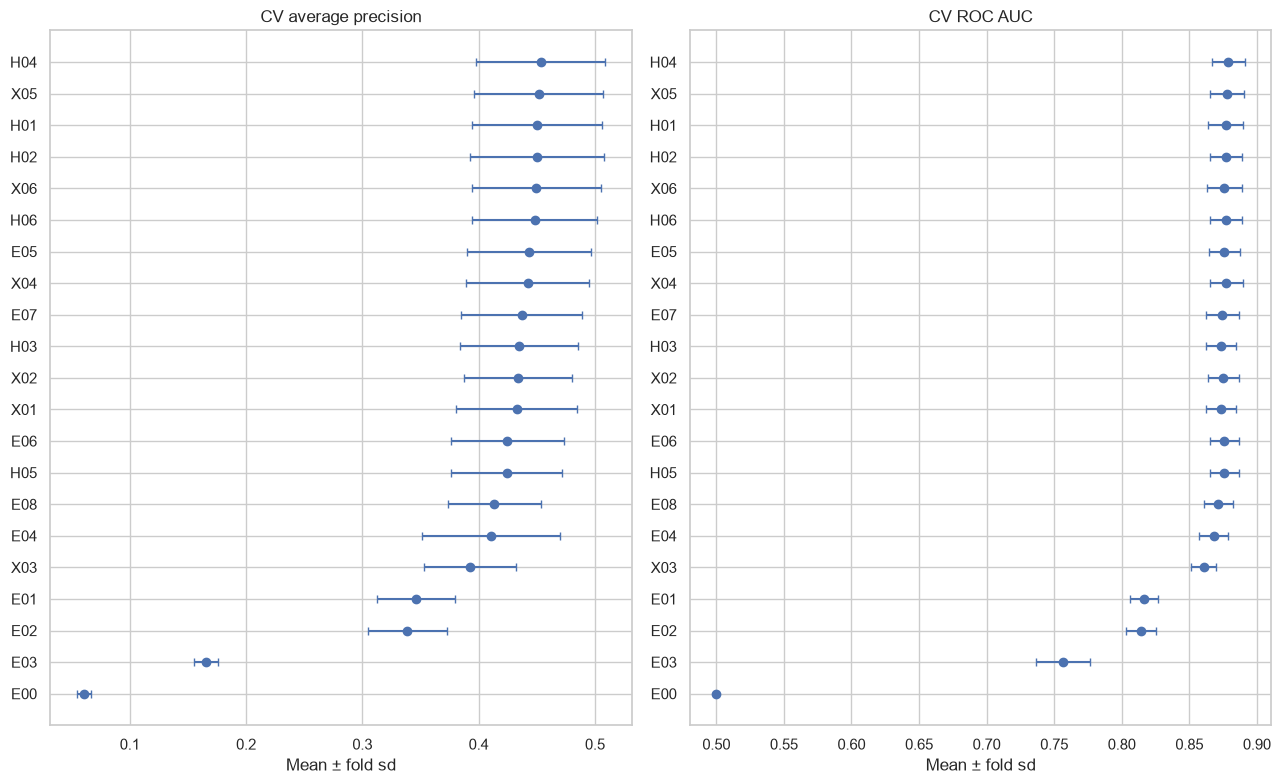

,dataset,sites,groups,positives,positive_rate,metric_status,average_precision,roc_auc,pr_auc_trapezoid,experiment_id,assessment_folds
36,data0,85166,2696,3845,0.045147,ok,0.477590,0.921585,0.477331,H04,5
37,data1,63568,2196,4591,0.072222,ok,0.393130,0.831904,0.392912,H04,5
38,data2,742,2,636,0.857143,ok,0.964987,0.822876,0.964948,H04,2


In [16]:
cv_display = experiment_results[["experiment_id", "family", "feature_set", "weighting"]].copy()
for metric, title in [("roc_auc", "ROC AUC"), ("pr_auc_trapezoid", "PR AUC (trapezoid)"), ("average_precision", "AP")]:
    cv_display[title + " mean ± sd"] = experiment_results.apply(
        lambda row: f"{row[metric + '_mean']:.4f} ± {row[metric + '_sd']:.4f}", axis=1,
    )
display(cv_display.set_index("experiment_id"))

paired_rows = []
for spec in experiments:
    if spec["parent"] is None:
        continue
    child = fold_results.loc[fold_results.experiment_id.eq(spec["experiment_id"])].set_index("fold")
    parent = fold_results.loc[fold_results.experiment_id.eq(spec["parent"])].set_index("fold")
    record = {"experiment_id": spec["experiment_id"], "parent": spec["parent"], "changed": spec["changed"]}
    for metric in ["roc_auc", "pr_auc_trapezoid", "average_precision"]:
        delta = child[metric] - parent[metric]
        record[f"delta_{metric}_mean"] = delta.mean()
        record[f"delta_{metric}_sd"] = delta.std(ddof=1)
    paired_rows.append(record)
paired_comparisons = pd.DataFrame(paired_rows)
display(paired_comparisons.loc[paired_comparisons.experiment_id.str.startswith("E")].round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 8))
plot_rows = experiment_results.iloc[::-1]
for ax, metric, title in zip(axes, ["average_precision", "roc_auc"], ["CV average precision", "CV ROC AUC"]):
    ax.errorbar(plot_rows[metric + "_mean"], np.arange(len(plot_rows)),
                xerr=plot_rows[metric + "_sd"], fmt="o", capsize=3)
    ax.set(yticks=np.arange(len(plot_rows)), yticklabels=plot_rows["experiment_id"],
           xlabel="Mean ± fold sd", title=title)
plt.tight_layout()
plt.show()
if SAVE_OUTPUTS:
    cv_display.to_csv(OUTPUT_DIR / "cv_mean_sd_report.csv", index=False)
    paired_comparisons.to_csv(OUTPUT_DIR / "paired_experiment_changes.csv", index=False)

# Pooled OOF scores within each dataset, plus the actual contributing folds.
# These are descriptive OOF metrics, not a five-fold mean for data2.
cv_dataset_rows = []
for experiment_id, scores in oof_scores.items():
    report = dataset_metrics(y_train, scores, metadata_train)
    report["experiment_id"] = experiment_id
    report["assessment_folds"] = report["dataset"].map(
        cv_manifest.reset_index().groupby("dataset")["assessment_fold"].nunique()
    )
    cv_dataset_rows.append(report)
cv_dataset_results = pd.concat(cv_dataset_rows, ignore_index=True)
display(cv_dataset_results.loc[cv_dataset_results.experiment_id.eq(best_experiment_id)])
if SAVE_OUTPUTS:
    cv_dataset_results.to_csv(OUTPUT_DIR / "cv_oof_metrics_by_dataset.csv", index=False)


## 12. Lock the CV winner, fit on all train, and select a validation threshold

Refit the selected configuration on X_train only. Also fit the predeclared prior, raw-mean HGB and sequence-logistic references for final comparison.
Model choice and hyperparameters are already fixed by CV; validation metrics are reported but do not reselect the model.
Choose the selected model's threshold using maximum validation F1 (largest threshold if tied).
Do not refit on train + validation afterward, because this would change the score distribution used to choose the threshold.


Locked model: H04: hgb (engineered, none); validation threshold: 0.208393


,average_precision,roc_auc,pr_auc_trapezoid
experiment_id,,,
E00,0.0642,0.5000,0.5321
E01,0.3658,0.8150,0.3655
E03,0.1670,0.7349,0.1784
H04,0.4967,0.8818,0.4965


,threshold,precision,recall,f1,specificity,balanced_accuracy,accuracy,tn,fp,fn,tp
rule,,,,,,,,,,,
default_0.5,0.5000,0.6590,0.2818,0.3948,0.9900,0.6359,0.9445,29395,297,1463,574
validation_max_f1,0.2084,0.5074,0.5376,0.5221,0.9642,0.7509,0.9368,28629,1063,942,1095


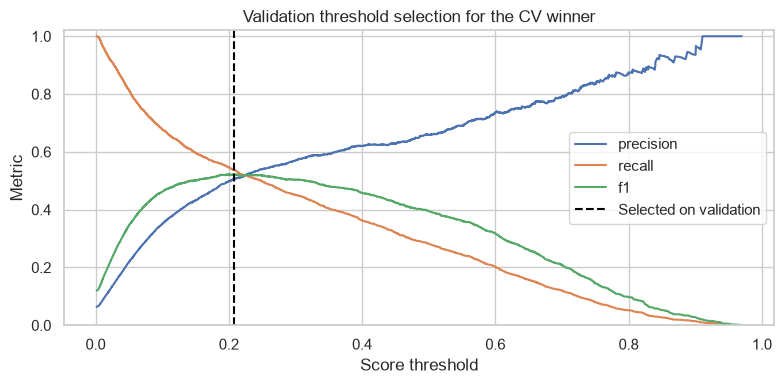

,dataset,sites,groups,positives,positive_rate,metric_status,...,fp,fn,tp,model,selected_by_cv,threshold_rule
0,data0,17735,575,793,0.044714,ok,...,0,793,0,E00,False,reference_0.5
1,data1,13665,480,962,0.070399,ok,...,0,962,0,E00,False,reference_0.5
2,data2,329,1,282,0.857143,ok,...,0,282,0,E00,False,reference_0.5
3,data0,17735,575,793,0.044714,ok,...,89,618,175,E01,False,reference_0.5
4,data1,13665,480,962,0.070399,ok,...,102,818,144,E01,False,reference_0.5
5,data2,329,1,282,0.857143,ok,...,0,246,36,E01,False,reference_0.5
6,data0,17735,575,793,0.044714,ok,...,5332,153,640,E03,False,reference_0.5
7,data1,13665,480,962,0.070399,ok,...,4159,328,634,E03,False,reference_0.5
8,data2,329,1,282,0.857143,ok,...,16,186,96,E03,False,reference_0.5
9,data0,17735,575,793,0.044714,ok,...,586,326,467,H04,True,validation_max_f1


In [17]:
reference_ids = ["E00", "E01", "E03"]
final_ids = list(dict.fromkeys([*reference_ids, best_experiment_id]))
final_models, final_fit_rows, validation_scores = {}, [], {}
for experiment_id in final_ids:
    spec = next(spec for spec in experiments if spec["experiment_id"] == experiment_id)
    model, realised = build_experiment_model(spec, y_train)
    with threadpool_limits(limits=MODEL_THREADS), warnings.catch_warnings():
        warnings.simplefilter("error", ConvergenceWarning)
        model.fit(X_train, y_train)
    final_models[experiment_id] = model
    final_fit_rows.append({"experiment_id": experiment_id, **realised})
    validation_scores[experiment_id] = positive_scores(model, X_val)
best_model = final_models[best_experiment_id]
best_val_scores = validation_scores[best_experiment_id]
validation_results = pd.DataFrame([
    {"experiment_id": name, **ranking_metrics(y_val, scores)}
    for name, scores in validation_scores.items()
]).set_index("experiment_id")
chosen_threshold, threshold_search = select_f1_threshold(y_val, best_val_scores)
validation_threshold_results = pd.DataFrame([
    {"rule": "default_0.5", **threshold_metrics(y_val, best_val_scores, 0.5)},
    {"rule": "validation_max_f1", **threshold_metrics(y_val, best_val_scores, chosen_threshold)},
]).set_index("rule")
print(f"Locked model: {best_model_name}; validation threshold: {chosen_threshold:.6f}")
display(validation_results.round(4), validation_threshold_results.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
for metric in ["precision", "recall", "f1"]:
    ax.plot(threshold_search["threshold"], threshold_search[metric], label=metric)
ax.axvline(chosen_threshold, color="black", linestyle="--", label="Selected on validation")
ax.set(title="Validation threshold selection for the CV winner", xlabel="Score threshold", ylabel="Metric", ylim=(0, 1.02))
ax.legend()
plt.tight_layout()
plt.show()

validation_dataset_results = pd.concat([
    dataset_metrics(y_val, scores, metadata_val,
                    chosen_threshold if name == best_experiment_id else 0.5).assign(
        model=name, selected_by_cv=name == best_experiment_id,
        threshold_rule="validation_max_f1" if name == best_experiment_id else "reference_0.5",
    )
    for name, scores in validation_scores.items()
], ignore_index=True)
display(validation_dataset_results)


## 13. Final evaluation on the pooled internal test partition

The experiment ID, hyperparameters and threshold are fixed before this cell. Compare the winner against predeclared references;
do not pick another winner from the test table. Report ROC-AUC, trapezoidal PR-AUC, AP, precision, recall, F1 and a confusion matrix.
These datasets were explored previously; this split provides internal evaluation rather than independent external validation.
Use one shared validation threshold for all dataset reports. A data2 test report covers one held-out construct and measures positive-mixture detection.


In [18]:
test_model_names = final_ids
test_scores = {
    name: positive_scores(final_models[name], X_test) for name in test_model_names
}
test_ranking_results = pd.DataFrame([
    {"model": name, **ranking_metrics(y_test, scores)}
    for name, scores in test_scores.items()
]).set_index("model")
test_ranking_results["selected_by_cv"] = test_ranking_results.index == best_experiment_id

best_test_scores = test_scores[best_experiment_id]
test_threshold_results = pd.DataFrame([
    {"rule": "default_0.5", **threshold_metrics(y_test, best_test_scores, 0.5)},
    {"rule": "validation_max_f1", **threshold_metrics(y_test, best_test_scores, chosen_threshold)},
]).set_index("rule")
test_predictions = metadata_test.join(y_test).assign(
    score=best_test_scores,
    prediction=(best_test_scores >= chosen_threshold).astype("int8"),
)
assert test_predictions.index.equals(y_test.index)
assert test_predictions["label"].equals(y_test)

print(f"Test sites: {len(y_test):,}; positive fraction: {y_test.mean():.4f}")
print(f"Final model: {best_model_name}; threshold selected on validation: {chosen_threshold:.6f}")
display(test_ranking_results.round(4), test_threshold_results.round(4))
test_classification_report = pd.DataFrame(classification_report(
    y_test, test_predictions["prediction"], labels=[0, 1],
    target_names=["unmodified (0)", "modified (1)"], zero_division=0, output_dict=True,
)).T
display(test_classification_report.round(4))

test_dataset_results = pd.concat([
    dataset_metrics(y_test, scores, metadata_test,
                    chosen_threshold if name == best_experiment_id else 0.5).assign(
        model=name, selected_by_cv=name == best_experiment_id,
        threshold_rule="validation_max_f1" if name == best_experiment_id else "reference_0.5",
    )
    for name, scores in test_scores.items()
], ignore_index=True)
display(test_dataset_results)


Test sites: 32,766; positive fraction: 0.0639
Final model: H04: hgb (engineered, none); threshold selected on validation: 0.208393


,average_precision,roc_auc,pr_auc_trapezoid,selected_by_cv
model,,,,
E00,0.0639,0.5000,0.5319,False
E01,0.3857,0.8287,0.3853,False
E03,0.1737,0.7539,0.1835,False
H04,0.5040,0.8877,0.5037,True


,threshold,precision,recall,f1,specificity,balanced_accuracy,accuracy,tn,fp,fn,tp
rule,,,,,,,,,,,
default_0.5,0.5000,0.6712,0.2819,0.397,0.9906,0.6362,0.9453,30384,289,1503,590
validation_max_f1,0.2084,0.5047,0.5385,0.521,0.9639,0.7512,0.9368,29567,1106,966,1127


,precision,recall,f1-score,support
unmodified (0),0.9684,0.9639,0.9661,30673.0000
modified (1),0.5047,0.5385,0.5210,2093.0000
accuracy,0.9368,0.9368,0.9368,0.9368
macro avg,0.7365,0.7512,0.7436,32766.0000
weighted avg,0.9387,0.9368,0.9377,32766.0000


,dataset,sites,groups,positives,positive_rate,metric_status,...,fp,fn,tp,model,selected_by_cv,threshold_rule
0,data0,18937,581,837,0.044199,ok,...,0,837,0,E00,False,reference_0.5
1,data1,13577,473,1040,0.076600,ok,...,0,1040,0,E00,False,reference_0.5
2,data2,252,1,216,0.857143,ok,...,0,216,0,E00,False,reference_0.5
3,data0,18937,581,837,0.044199,ok,...,86,648,189,E01,False,reference_0.5
4,data1,13577,473,1040,0.076600,ok,...,107,872,168,E01,False,reference_0.5
5,data2,252,1,216,0.857143,ok,...,0,183,33,E01,False,reference_0.5
6,data0,18937,581,837,0.044199,ok,...,5565,156,681,E03,False,reference_0.5
7,data1,13577,473,1040,0.076600,ok,...,4039,278,762,E03,False,reference_0.5
8,data2,252,1,216,0.857143,ok,...,11,150,66,E03,False,reference_0.5
9,data0,18937,581,837,0.044199,ok,...,618,326,511,H04,True,validation_max_f1


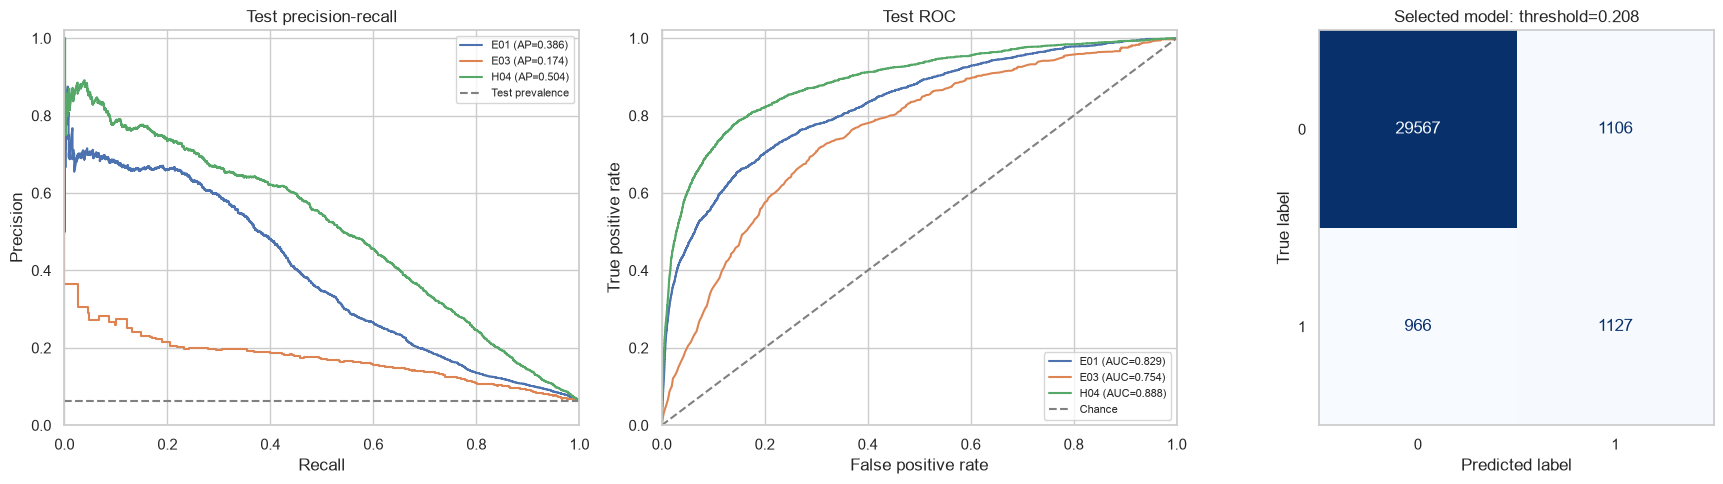

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for name, scores in test_scores.items():
    if name == "E00":
        continue  # Show its no-skill references as lines instead.
    precision, recall, _ = precision_recall_curve(y_test, scores)
    fpr, tpr, _ = roc_curve(y_test, scores)
    ap = test_ranking_results.loc[name, "average_precision"]
    roc = test_ranking_results.loc[name, "roc_auc"]
    axes[0].step(recall, precision, where="post", label=f"{name} (AP={ap:.3f})")
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={roc:.3f})")
axes[0].axhline(y_test.mean(), color="gray", linestyle="--", label="Test prevalence")
axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Chance")
axes[0].set(title="Test precision-recall", xlabel="Recall", ylabel="Precision", xlim=(0, 1), ylim=(0, 1.02))
axes[1].set(title="Test ROC", xlabel="False positive rate", ylabel="True positive rate", xlim=(0, 1), ylim=(0, 1.02))
for ax in axes[:2]:
    ax.legend(fontsize=8, loc="best")
ConfusionMatrixDisplay.from_predictions(
    y_test, test_predictions["prediction"], labels=[0, 1],
    display_labels=["0", "1"], values_format="d", colorbar=False,
    cmap="Blues", ax=axes[2],
)
axes[2].set_title(f"Selected model: threshold={chosen_threshold:.3f}")
axes[2].grid(False)
plt.tight_layout()
plt.show()


## 14. Group-bootstrap intervals for the fixed selected model

Resample whole human test genes (500 repeats), carrying observations from both datasets together.
Keep group kinds separate and resample the same number of groups within each kind to preserve the human/synthetic composition.
The single held-out data2 construct is necessarily fixed in these pooled intervals: they **cannot estimate uncertainty across synthetic constructs**.
Intervals are conditional on this fitted model and these datasets, and omit training/selection uncertainty.
No per-dataset data2 interval is claimed. These intervals are separate from the CV mean ± sd report.


In [20]:
def gene_bootstrap_metrics(y_true, scores, genes, threshold, n_bootstrap=BOOTSTRAP_REPEATS, seed=SEED, strata=None):
    if not y_true.index.equals(genes.index):
        raise ValueError("Gene metadata must align with the label index.")
    if genes.isna().any() or n_bootstrap < 1:
        raise ValueError("Genes must be populated and n_bootstrap must be positive.")
    codes, unique_genes = pd.factorize(genes, sort=True)
    if strata is None:
        pools = [np.arange(len(unique_genes))]
    else:
        if not strata.index.equals(genes.index) or strata.isna().any():
            raise ValueError("Bootstrap strata must align with groups.")
        group_strata = pd.DataFrame({"group": genes, "stratum": strata})
        if not group_strata.groupby("group")["stratum"].nunique().eq(1).all():
            raise ValueError("Each group needs exactly one bootstrap stratum.")
        kinds = group_strata.drop_duplicates("group").set_index("group")["stratum"].reindex(unique_genes)
        pools = [np.flatnonzero(kinds.to_numpy() == kind) for kind in sorted(kinds.unique())]
    rng = np.random.default_rng(seed)
    labels = y_true.to_numpy()
    predictions = (np.asarray(scores) >= threshold).astype("int8")
    samples = []
    for _ in range(n_bootstrap):
        gene_counts = np.bincount(
            np.concatenate([pool[rng.integers(0, len(pool), size=len(pool))] for pool in pools]),
            minlength=len(unique_genes),
        )
        weights = gene_counts[codes]
        if np.unique(labels[weights > 0]).size != 2:
            continue
        samples.append({
            "average_precision": average_precision_score(labels, scores, sample_weight=weights),
            "roc_auc": roc_auc_score(labels, scores, sample_weight=weights),
            "f1": f1_score(labels, predictions, sample_weight=weights, zero_division=0),
        })
    if len(samples) < 0.9 * n_bootstrap:
        raise ValueError("Too many bootstrap samples lack both classes for reliable intervals.")
    return pd.DataFrame(samples)

bootstrap_samples = gene_bootstrap_metrics(
    y_test, best_test_scores, metadata_test["group_id"], chosen_threshold, strata=metadata_test["group_kind"],
)
point_estimates = {
    "average_precision": test_ranking_results.loc[best_experiment_id, "average_precision"],
    "roc_auc": test_ranking_results.loc[best_experiment_id, "roc_auc"],
    "f1": test_threshold_results.loc["validation_max_f1", "f1"],
}
test_confidence_intervals = pd.DataFrame({
    "estimate": pd.Series(point_estimates),
    "lower_95": bootstrap_samples.quantile(0.025),
    "upper_95": bootstrap_samples.quantile(0.975),
})
print(f"Valid group-bootstrap samples: {len(bootstrap_samples)} / {BOOTSTRAP_REPEATS}")
display(test_confidence_intervals.round(4))


Valid group-bootstrap samples: 500 / 500


,estimate,lower_95,upper_95
average_precision,0.5040,0.4697,0.5400
roc_auc,0.8877,0.8761,0.8982
f1,0.5210,0.4924,0.5507


## 15. Recommend the final model and save the complete experiment record

The recommendation is determined by training CV, with validation used only for the threshold. Save the evaluated train-only model with its preprocessing,
feature schema, experiment specification, threshold, package versions, data lineage and known evaluation limitations.
Every run contains its own results log; a cumulative history CSV also records completed experiments from all runs.
This completes the Person C technical deliverables without backdating execution or treating the internal test as unseen data.


In [21]:
selected_cv = experiment_results.set_index("experiment_id").loc[best_experiment_id]
mean_baseline_cv = experiment_results.set_index("experiment_id").loc["E01"]
recommendation = {
    "run_id": RUN_ID, "recommended_at": datetime.now(LOCAL_TZ).isoformat(),
    "selected_experiment": best_experiment_id, "model_name": best_model_name,
    "specification": best_spec, "datasets": list(DATASETS),
    "test_by_dataset": test_dataset_results.loc[test_dataset_results.selected_by_cv].to_dict(orient="records"),
    "selection_reason": "Highest mean five-fold gene/construct-grouped training CV AP; ROC-AUC breaks ties.",
    "cv_metrics": {name: float(selected_cv[name]) for name in selected_cv.index
                   if name.endswith(("_mean", "_sd"))},
    "cv_ap_gain_over_raw_mean_baseline": float(selected_cv.average_precision_mean - mean_baseline_cv.average_precision_mean),
    "validation_threshold": chosen_threshold,
    "internal_test_ranking": test_ranking_results.loc[best_experiment_id].to_dict(),
    "internal_test_threshold_metrics": test_threshold_results.loc["validation_max_f1"].to_dict(),
    "limitations": [
        "CV scores were used for tuning and selection; they are not nested-CV unbiased performance estimates.",
        "These datasets were explored previously; the new pooled internal split is not external validation.",
        "Pooled selection weights sites equally, so larger datasets dominate; inspect dataset reports.",
        "data2 has only two training constructs and one each in validation/test; its labels mean positive mixture.",
        "Synthetic assignments retain inferred mapping evidence; splitting is conditional on those assignments.",
        "Group-bootstrap intervals cannot estimate uncertainty across synthetic constructs from one test construct.",
        "Weighted scores are not guaranteed to be calibrated modification probabilities.",
        "No claim is made that the original September/October deadlines were met.",
    ],
}
recommendation_text = (
    f"**Recommended model: {best_model_name}.**\n\n"
    f"Five-fold gene/construct-grouped CV: ROC-AUC **{selected_cv.roc_auc_mean:.4f} ± {selected_cv.roc_auc_sd:.4f}**, "
    f"PR-AUC (trapezoid) **{selected_cv.pr_auc_trapezoid_mean:.4f} ± {selected_cv.pr_auc_trapezoid_sd:.4f}**, "
    f"AP **{selected_cv.average_precision_mean:.4f} ± {selected_cv.average_precision_sd:.4f}**. "
    f"Mean AP changes by **{recommendation['cv_ap_gain_over_raw_mean_baseline']:+.4f}** relative to the raw-mean HGB baseline.\n\n"
    f"Use the validation-selected threshold **{chosen_threshold:.4f}** for the reported precision/recall trade-off. "
    "This recommendation uses CV scores, not test ranking. Pooled test results are internal checks; inspect the three dataset reports separately."
)
display(Markdown(recommendation_text))

model_bundle = {
    "model": best_model, "model_name": best_model_name, "experiment": best_spec,
    "threshold": chosen_threshold, "feature_columns": list(X_train.columns),
    "selected_feature_columns": FEATURE_SETS[best_spec["feature_set"]],
    "raw_mean_columns": RAW_MEAN_COLUMNS, "engineered_columns": FEATURE_COLUMNS,
    "seed": SEED, "selection_metric": "mean_pooled_training_GroupKFold_average_precision",
    "threshold_rule": "maximum_validation_f1_largest_threshold_on_tie",
    "training_partition": "train_only", "group_column": "group_id",
    "datasets": list(DATASETS), "observation_keys": OBSERVATION_KEYS,
    "data2_label_rule": "label_original > 0",
    "kmer_residuals": False, "versions": versions, "run_id": RUN_ID,
}
if SAVE_OUTPUTS:
    joblib.dump(model_bundle, OUTPUT_DIR / "selected_model.joblib", compress=3)
    validation_dataset_results.to_csv(OUTPUT_DIR / "validation_metrics_by_dataset.csv", index=False)
    test_dataset_results.to_csv(OUTPUT_DIR / "test_metrics_by_dataset.csv", index=False)
    validation_results.to_csv(OUTPUT_DIR / "validation_ranking_metrics.csv")
    validation_threshold_results.to_csv(OUTPUT_DIR / "validation_threshold_metrics.csv")
    threshold_search.to_csv(OUTPUT_DIR / "validation_threshold_search.csv", index=False)
    test_ranking_results.to_csv(OUTPUT_DIR / "test_ranking_metrics.csv")
    test_threshold_results.to_csv(OUTPUT_DIR / "test_threshold_metrics.csv")
    test_classification_report.to_csv(OUTPUT_DIR / "test_classification_report.csv")
    test_confidence_intervals.to_csv(OUTPUT_DIR / "test_group_bootstrap_intervals.csv")
    test_predictions.to_parquet(OUTPUT_DIR / "test_predictions.parquet", index=True)
    pd.DataFrame(final_fit_rows).to_csv(OUTPUT_DIR / "final_fit_weights.csv", index=False)
    (OUTPUT_DIR / "recommendation.json").write_text(json.dumps(recommendation, indent=2), encoding="utf-8")
    reloaded_bundle = joblib.load(OUTPUT_DIR / "selected_model.joblib")
    reloaded_scores = positive_scores(reloaded_bundle["model"], X_val[reloaded_bundle["feature_columns"]])
    np.testing.assert_allclose(reloaded_scores, best_val_scores, rtol=1e-12, atol=1e-12)
    assert reloaded_bundle["threshold"] == chosen_threshold
    pd.testing.assert_frame_equal(pd.read_csv(OUTPUT_DIR / "experiment_log.csv"),
                                  pd.DataFrame(experiment_summaries), check_dtype=False, atol=1e-12)
    print("PASS: saved experiment log and reloaded model verified.")
    print("Complete run directory:", OUTPUT_DIR)
    print("Cumulative experiment history:", OUTPUT_BASE / "person_c_experiment_history.csv")
else:
    print("Model, logs and recommendation remain in memory; enable SAVE_OUTPUTS to persist them.")


**Recommended model: H04: hgb (engineered, none).**

Five-fold gene/construct-grouped CV: ROC-AUC **0.8788 ± 0.0124**, PR-AUC (trapezoid) **0.4528 ± 0.0559**, AP **0.4532 ± 0.0557**. Mean AP changes by **+0.1071** relative to the raw-mean HGB baseline.

Use the validation-selected threshold **0.2084** for the reported precision/recall trade-off. This recommendation uses CV scores, not test ranking. Pooled test results are internal checks; inspect the three dataset reports separately.

PASS: saved experiment log and reloaded model verified.
Complete run directory: /Users/jiacheng/Documents/GitHub/DSA4262_Genomies/data/processed/modelling/pooled_data0_data1_data2_group_split_seed42/person_c_runs/20261006T085253_d868f3c6
Cumulative experiment history: /Users/jiacheng/Documents/GitHub/DSA4262_Genomies/data/processed/modelling/pooled_data0_data1_data2_group_split_seed42/person_c_experiment_history.csv


## Deliverable map and interpretation

| Person C item | Evidence |
|---|---|
| GroupKFold by shared gene / construct | `cv_fold_manifest.parquet`; disjoint-group assertions; five shared folds |
| ROC AUC / PR AUC mean ± sd | `cv_mean_sd_report.csv`, `cv_leaderboard.csv`, `fold_results.csv` |
| Mean-feature boosting baseline | Experiment E01: exactly nine arithmetic raw signal means |
| Class imbalance | E01/E02, E05/E06 and E07/E08 paired comparisons; logged fold-training weights |
| Hyperparameter tuning | H01–H06 and X01–X06; sampled search spaces and complete parameter records |
| Compare models | Identical CV folds, leaderboard and `paired_experiment_changes.csv` |
| Results log | `experiment_log.csv`, per-fold log and cumulative `person_c_experiment_history.csv` |
| Final recommendation | `recommendation.json`, displayed recommendation and `selected_model.joblib` |

Model evaluation is site-level. Shared human genes and synthetic constructs determine the grouping and bootstrap units.
`split_dataset_summary.csv`, `cv_oof_metrics_by_dataset.csv`, `validation_metrics_by_dataset.csv` and `test_metrics_by_dataset.csv` provide dataset-level reports.
Higher AP does not imply that most positive predictions are correct; inspect the reported threshold, precision, recall and confusion matrix together.
For future experiments, use training CV for changes and seek external validation; do not repeatedly select changes based on the internal test results.
The separate m6Anet benchmark from the broader project handout is outside this Person C checklist.

References: [GroupKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GroupKFold.html),
[average precision](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html),
[XGBoost parameters and scale_pos_weight](https://xgboost.readthedocs.io/en/stable/parameter.html).
